In [1]:
import pandas as pd
import math

In [2]:
grampa_path = 'data/origin_data/grampa.csv'
negative_file_path = 'data/origin_data/origin_negative.csv'

### Generate Sample Class

In [3]:
class GenerateSample():
    def __init__(self, grampa_path, negative_file_path):
        self.grampa_path = grampa_path
        self.negative_file_path = negative_file_path
        self.positive_samples = None
        self.negative_samples = None
        self.all_samples = None

    def __call__(self, *args, **kwargs):
        grampa_data = pd.read_csv(self.grampa_path, encoding="utf8")
        grampa_data = self.filter_data_with_str("bacterium", "aureus", grampa_data)
        self.positive_samples = self.generate_all_peptides(grampa_data)
        self.negative_samples = self.generate_negative_data(self.negative_file_path)
        self.all_samples = self.concat_datasets(self.positive_samples, self.negative_samples)
        

    def filter_data_with_str(self, col_name, str, data):

        bool_filter = data[col_name].str.contains(str)
        filter_data = data[bool_filter]
        return filter_data

    def generate_all_peptides(self, data):

        data_all = [[], [], []]
        for i in data["sequence"].unique():
            data_all[0].append(i)
            log_num = 0
            count = 0
            for i in data[data["sequence"] == i]["value"]:
                log_num += math.pow(10, i)
                count += 1
            data_all[1].append(float(log_num / count))
            data_all[2].append(1)

        data_all = list(map(list, zip(*data_all)))
        data = pd.DataFrame(data=data_all, columns=["sequence", "MIC", "type"])
        return data

    def data2csv(self, data, file_name):

        data.to_csv(file_name, encoding="utf8", index=False)

    def generate_negative_data(self, negative_file_path):

        data_negative = pd.read_csv(negative_file_path, encoding="utf8")
        # removes entries with unknown and uncommon amino acid identifiers
        data_negative = data_negative[~data_negative["Sequence"].str.contains("B|X|Z|O|U")]
        data_negative.reset_index(drop=True, inplace=True)
        data = data_negative.rename(columns={'Sequence': 'sequence'}).assign(MIC=8196).assign(type=0)[['sequence', 'MIC', 'type']]

        return data


    def concat_datasets(self, positive_file, negative_file):

        data_concat = pd.concat([positive_file, negative_file], ignore_index=True, axis=0)  # 默认纵向合并0 横向合并1
        data_concat = data_concat.sample(frac=1,random_state=None)
        data_concat.reset_index(drop=True, inplace=True)
        return data_concat

    def split_sample(self, sample):
        num = len(sample)
        train_sample = sample[:int(0.8 * num)]
        test_sample = sample[int(0.8 * num):]
        self.data2csv(train_sample, self.generate_example_path + "regression_train_sample.csv")
        self.data2csv(test_sample, self.generate_example_path + "regression_test_sample.csv")


### Generating samples according to papers library

In [4]:
samples = GenerateSample(grampa_path, negative_file_path)
samples()

In [6]:
x = [samples.positive_samples,
samples.negative_samples,
samples.all_samples]
label = ['positive_samples', 'negative_samples', 'all_samples']
print('Using the code from the paper we get the following amount of data.')
for i, l in zip(x, label):
    print('-'*50)
    print(l)
    print(len(i))

Using the code from the paper we get the following amount of data.
--------------------------------------------------
positive_samples
4582
--------------------------------------------------
negative_samples
8047
--------------------------------------------------
all_samples
12629


# Making negative examples from UniProt Database

## Processing

In [7]:
data_negative = pd.read_csv(negative_file_path, encoding="utf8").rename(columns={'Protein names': 'protein_names'})
print(f'Original Negative data: {len(data_negative)}')

Original Negative data: 8556


In [8]:
print(data_negative.describe())
print(data_negative.info())

            Length
count  8556.000000
mean     25.168887
std      11.024466
min       2.000000
25%      14.000000
50%      28.000000
75%      36.000000
max      40.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8556 entries, 0 to 8555
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Entry          8556 non-null   object
 1   Status         8556 non-null   object
 2   protein_names  8556 non-null   object
 3   Organism       8556 non-null   object
 4   Length         8556 non-null   int64 
 5   Keywords       8455 non-null   object
 6   Sequence       8556 non-null   object
 7   Features       8556 non-null   object
dtypes: int64(1), object(7)
memory usage: 534.9+ KB
None


## Remove unknown amino acids

In [9]:
data_negative = data_negative[~data_negative["Sequence"].str.contains("B|X|Z|O|U")]
data_negative.reset_index(drop=True, inplace=True)

In [10]:
data_negative.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8047 entries, 0 to 8046
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Entry          8047 non-null   object
 1   Status         8047 non-null   object
 2   protein_names  8047 non-null   object
 3   Organism       8047 non-null   object
 4   Length         8047 non-null   int64 
 5   Keywords       7947 non-null   object
 6   Sequence       8047 non-null   object
 7   Features       8047 non-null   object
dtypes: int64(1), object(7)
memory usage: 503.1+ KB


## Assign MIC value to negative samples (Absurdly high MIC)

In [11]:
data = data_negative.rename(columns={'Sequence': 'sequence'}).assign(MIC=8196).assign(type=0)[['sequence', 'MIC', 'type']]
data.head()

,sequence,MIC,type
0,QVNFSTGW,8196,0
1,TMCYSHTTTSRAILTNCGENSCYRKSRVHP,8196,0
2,MAPPSIFAEVPQAQPVLVFKLTADFREDPDP,8196,0
3,SVAVAGAVIEGASLTFNVLQ,8196,0
4,GFKNVALSTARGF,8196,0


## Filter by sequence length. Keep peptides between 0 - 40 AAs long

In [12]:
x = data.sequence.map(lambda x: True if 0 < len(x) < 40 else False)
data = data[x]

## Results

In [15]:
print('The paper reports 5,898 negative samples')

The paper reports 5,898 negative samples


In [16]:
print(len(data), 'NEGATIVE SAMPLES after filtering by sequence and amino acids.')

7772 NEGATIVE SAMPLES after filtering by sequence and amino acids.


# Making positive data

## Processing

In [106]:
grampa_data = pd.read_csv(grampa_path, encoding="utf8").drop('Unnamed: 0', axis=1)
grampa_data.head()

,bacterium,modifications,sequence,strain,unit,url_source,value,is_modified,has_unusual_modification,has_cterminal_amidation,datasource_has_modifications,database
0,B. subtilis,[disulfide],GLPRKILCAIAKKKGKCKGPLKLVCKC,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,-0.397940,True,False,False,True,APD
1,S. agalactiae,[disulfide],GFGCPGDAYQCSEHCRALGGGRTGGYCAGPWYLGHPTCTCSF,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,-1.859819,True,False,False,True,APD
2,S. aureus,[disulfide],GFGCPGDAYQCSEHCRALGGGRTGGYCAGPWYLGHPTCTCSF,ATCC29213,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.566150,True,False,False,True,APD
3,S. pneumonia,[disulfide],GFGCPGDAYQCSEHCRALGGGRTGGYCAGPWYLGHPTCTCSF,ATCC49619,uM,http://aps.unmc.edu/AP/database/query_output.p...,-1.240030,True,False,False,True,APD
4,S. epidermidis,[disulfide],GFGCPGDAYQCSEHCRALGGGRTGGYCAGPWYLGHPTCTCSF,ATCC12228,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.566150,True,False,False,True,APD


In [107]:
grampa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51345 entries, 0 to 51344
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bacterium                     51345 non-null  object 
 1   modifications                 51345 non-null  object 
 2   sequence                      51345 non-null  object 
 3   strain                        29111 non-null  object 
 4   unit                          51345 non-null  object 
 5   url_source                    51345 non-null  object 
 6   value                         51345 non-null  float64
 7   is_modified                   51345 non-null  bool   
 8   has_unusual_modification      51345 non-null  bool   
 9   has_cterminal_amidation       51345 non-null  bool   
 10  datasource_has_modifications  51345 non-null  bool   
 11  database                      51345 non-null  object 
dtypes: bool(4), float64(1), object(7)
memory usage: 3.3+ MB


## Filter by target aureus

In [108]:
col_name = "bacterium"
target = "aureus"

bool_filter = grampa_data[col_name].str.contains(target)
filter_data = grampa_data[bool_filter]

In [109]:
filter_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8955 entries, 2 to 51341
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bacterium                     8955 non-null   object 
 1   modifications                 8955 non-null   object 
 2   sequence                      8955 non-null   object 
 3   strain                        5209 non-null   object 
 4   unit                          8955 non-null   object 
 5   url_source                    8955 non-null   object 
 6   value                         8955 non-null   float64
 7   is_modified                   8955 non-null   bool   
 8   has_unusual_modification      8955 non-null   bool   
 9   has_cterminal_amidation       8955 non-null   bool   
 10  datasource_has_modifications  8955 non-null   bool   
 11  database                      8955 non-null   object 
dtypes: bool(4), float64(1), object(7)
memory usage: 664.6+ KB


data filtering on target aureus reduces data from 51345 to 8955 entries

In [110]:
filter_data.head()

,bacterium,modifications,sequence,strain,unit,url_source,value,is_modified,has_unusual_modification,has_cterminal_amidation,datasource_has_modifications,database
2,S. aureus,[disulfide],GFGCPGDAYQCSEHCRALGGGRTGGYCAGPWYLGHPTCTCSF,ATCC29213,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.566150,True,False,False,True,APD
7,S. aureus,[],LVKDNPLDISPKQVQALCTDLVIRCMCCC,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.491362,False,False,False,True,APD
11,S. aureus,[],YPELQQDLIARLL,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.799341,False,False,False,True,APD
15,S. aureus,[disulfide],GVFTLIKGATQLIGKTLGKELGKTGLELMACKITEQC,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.556303,True,False,False,True,APD
19,S. aureus,[disulfide],FLPAIAGMAAKFLPKIFCAISKKC,NaN,uM,http://aps.unmc.edu/AP/database/query_output.p...,0.000000,True,False,False,True,APD


### Keep only lengths between 5 and 50 AA long

In [125]:
# Lets remove sequences above 40 long
x = filter_data.sequence.map(lambda x: True if 5 <= len(x) <= 50 else False)
x.value_counts()

True     8658
False     297
Name: sequence, dtype: int64

In [126]:
grampa_filtered = filter_data[x]

### Convert logMIC to MIC

In [127]:
print('statistics for logMIC values')
grampa_filtered.value.describe()

statistics for logMIC values


count    8658.000000
mean        1.077654
std         0.745624
min        -2.612581
25%         0.544343
50%         1.000000
75%         1.602060
max         3.961909
Name: value, dtype: float64

In [128]:
grampa_filtered = grampa_filtered.assign(MIC = lambda x: 10**x['value'])
print('statistics for MIC values')
grampa_filtered.MIC.describe()

statistics for MIC values


count    8658.000000
mean       63.473947
std       263.696794
min         0.002440
25%         3.502219
50%        10.000000
75%        40.000000
max      9160.286100
Name: MIC, dtype: float64

### Keep only c-terminal amyddation

In [129]:
grampa_filtered = grampa_filtered[grampa_filtered.has_cterminal_amidation == True]

In [130]:
nunique_sequences = grampa_filtered.sequence.nunique()
print(f'There are {nunique_sequences} unique sequences in the filtered dataset')

There are 1920 unique sequences in the filtered dataset


In [131]:
m = grampa_filtered.has_unusual_modification == False
grampa_filtered = grampa_filtered[m]

In [134]:
nunique_sequences = grampa_filtered.sequence.nunique()
print(f'There are {nunique_sequences} unique sequences in the filtered dataset')

There are 1737 unique sequences in the filtered dataset


In [138]:
average_MIC_unique_sequences = grampa_filtered.groupby('sequence').agg({'MIC': ['mean', 'size']})
average_MIC_unique_sequences.columns = average_MIC_unique_sequences.columns.droplevel()
average_MIC_unique_sequences = average_MIC_unique_sequences.rename(columns={'mean': 'logMIC_mean', 'size': 'occurences'})

In [139]:
average_MIC_unique_sequences.occurences.sum()

2558

In [140]:
average_MIC_unique_sequences.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1737 entries, AAAAAAAIKMLMDLVNERIMALNKKAKK to YWRWRW
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   logMIC_mean  1737 non-null   float64
 1   occurences   1737 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 40.7+ KB


In [141]:
average_MIC_unique_sequences.describe()

,logMIC_mean,occurences
count,1737.000000,1737.000000
mean,44.959455,1.472654
std,72.819030,0.933550
min,0.020000,1.000000
25%,4.666667,1.000000
50%,14.813318,1.000000
75%,52.924524,2.000000
max,536.456857,9.000000


## Check MIC distribution

(0.0, 100.0)

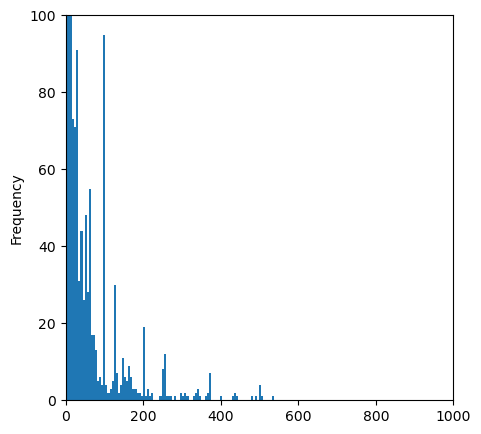

In [142]:
import matplotlib.pyplot as plt

_, ax = plt.subplots(1,1, figsize=(5,5))
average_MIC_unique_sequences.logMIC_mean.plot.hist(bins=100, ax=ax)
ax.set_xlim([0,1000])
ax.set_ylim([0, 100])

In [143]:
avg_MIC_less_than_8196_2 = average_MIC_unique_sequences[average_MIC_unique_sequences.logMIC_mean <= 8196//2]

In [144]:
print(f'There are {len(average_MIC_unique_sequences)} before MIC cutoff')
print(f'There are {len(avg_MIC_less_than_8196_2)} after filtering by MIC cutoff')
print(f'This is compared to the 1762 reported in the paper and 4,582 from the github repo for the paper')

There are 1737 before MIC cutoff
There are 1737 after filtering by MIC cutoff
This is compared to the 1762 reported in the paper and 4,582 from the github repo for the paper
